# 04 - Deep Networks

**AI sin humo** - Notas personales para entender deep learning desde cero.

Ya sabemos que una shallow network puede aproximar cualquier función continua (teorema del aproximador universal). Entonces, ¿para qué complicarnos con más capas? Respuesta corta: **eficiencia**. Las deep networks crean muchas más regiones lineales usando muchos menos parámetros. Y eso es lo que hace que el deep learning sea práctico.

---

## Contenido

1. [¿Por qué profundidad?](#por-que)
2. [Composición de shallow networks](#composicion)
3. [El "folding" del espacio](#folding)
4. [De composición a deep network](#composicion-a-deep)
5. [Notación matricial](#notacion-matricial)
6. [Implementación](#implementacion)
7. [Visualización capa por capa](#visualizacion)
8. [Comparación: shallow vs deep](#comparacion)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---

<a id='por-que'></a>
## 1. ¿Por qué profundidad?

Ya con las shallow networks podemos hacer todo lo que queremos. No sería en principio necesario hacer más nada. Sin embargo, para algunas funciones complejas, la cantidad de neuronas que se necesitan en la hidden layer son **MUCHAS**.

Con deep networks (que son composiciones de muchas capas, en vez de una), se pueden crear **muchas más regiones lineales usando menos parámetros**. Es una cuestión de **eficiencia computacional**.

### El argumento numérico

Supongamos que tenemos un presupuesto de $n = 6$ neuronas en total:

| Configuración | Regiones lineales máximas |
|:-------------|:-------------------------:|
| **Shallow** (6 units en 1 capa) | $n + 1 = 7$ |
| **Deep** (3 + 3 en 2 capas) | $4 \times 4 = 16$ |

¡Con la misma cantidad de parámetros, la deep network crea **más del doble** de regiones!

¿Por qué pasa esto? Porque cada capa "multiplica" las regiones de la anterior en vez de simplemente sumarlas. Veamos cómo.

---

<a id='composicion'></a>
## 2. Composición de shallow networks

Si en vez de terminar con el output, lo que hacemos es pasarlo por **OTRA** shallow network, lo que hacemos es pasar de una dimensión de input a otra de output y esto mandarlo a una nueva red shallow.

![Composición de dos shallow networks](../ai_notas/AI%20notas/image%2026.png)

### ¿Qué pasa con las regiones?

Lo que hacemos acá es que, si tenemos 3 regiones lineales en la primera red, para distintos valores de input le puede corresponder el mismo valor de la primera red (eso está claro, porque la primera red genera una función con pocos valores). Entonces esos tres valores diferentes de input mapean de la misma manera a un lugar de la segunda network.

Si vemos el mapeo desde el input $x$ a la network 2, es como que se **triplica** todo de una manera escalada.

Para $n = 6$ units:
- **Shallow**: tenemos como máximo $n + 1 = 7$ regiones lineales
- **Compuesta**: 4 regiones para la primera red y 4 para la otra. Como para cada región le corresponde la **total combinación** con la totalidad de la red 2, se particionan $\times 4$, quedando **16 regiones lineales**.

---

<a id='folding'></a>
## 3. El "folding" del espacio

Se puede ver como que para cada región de la red 1 le corresponde toda la transformación de la red 2. Es como **doblar el espacio** y aplicarle toda la red 2 a cada pliegue (fold).

![Folding del espacio](../ai_notas/AI%20notas/image%2027.png)

Es como que se "copia" la red 2 para cada pliegue de la red 1 y se escala según el tamaño del pliegue de la red 1.

**No hay que pensarlo como que se multiplican** ni nada, sino que se copia la red 2. A su vez, como se dobla el espacio de inputs:
- La primera parte queda en un sentido (el sentido normal)
- La segunda queda en el **otro sentido** (porque se está doblando para el otro lado)
- La tercera queda en el sentido normal de nuevo

Entonces al aplicar la segunda red, la segunda parte queda como **invertida**.

Esta intuición del folding es útil para entender por qué las deep networks son tan eficientes: cada capa no suma regiones, las **multiplica**.

---

<a id='composicion-a-deep'></a>
## 4. De composición a deep network

En realidad vemos que no es necesario "encapsular" todo el resultado de la hidden layer 1 en una neurona "y" y después pasar eso como input a la otra red. Si simplemente **conectamos cada neurona de la hidden layer 2 a cada neurona de la hidden layer 1**, es lo mismo pero con una **familia de funciones más amplia**.

![De composición a deep network](../ai_notas/AI%20notas/image%2028.png)

![Deep network completa](../ai_notas/AI%20notas/image%2029.png)

Esto es una **deep network**: múltiples capas ocultas conectadas entre sí, donde cada neurona de una capa se conecta a todas las neuronas de la capa siguiente. Esto se llama **fully connected** o **dense**.

Cada capa hace exactamente lo mismo:
1. **Transformación lineal**: multiplicación de la entrada por una matriz de pesos + bias
2. **Activación no lineal**: ReLU (u otra)

Y se repite esto capa tras capa. Eso es todo lo que es una deep network.

---

<a id='notacion-matricial'></a>
## 5. Notación matricial

Las redes son secuencias de **transformaciones lineales + funciones de activación**. Todo se puede escribir de forma compacta con matrices:

![Notación matricial](../ai_notas/AI%20notas/image%2030.png)

Para una red con:
- Input: 1D
- Hidden layers: 2
- Hidden units por layer: 3
- Activación: ReLU

El **forward pass** (pasar datos por la red) es:

$$\mathbf{h}_1 = \text{ReLU}(\mathbf{W}_1 \cdot \mathbf{x} + \mathbf{b}_1)$$
$$\mathbf{h}_2 = \text{ReLU}(\mathbf{W}_2 \cdot \mathbf{h}_1 + \mathbf{b}_2)$$
$$\mathbf{y} = \mathbf{W}_3 \cdot \mathbf{h}_2 + \mathbf{b}_3$$

Donde:
- $\mathbf{W}_k$ son **matrices de pesos** de la capa $k$
- $\mathbf{b}_k$ son **vectores de bias** de la capa $k$
- $\mathbf{h}_k$ es el **output** de la capa $k$ (después de la activación)
- La última capa (output) normalmente **no tiene activación** (o tiene una específica como softmax para clasificación)

![Red descrita con matrices](../ai_notas/AI%20notas/image%2031.png)

La forma de describir una red es:
- **Dimensión del input**: cuántos features tiene cada dato
- **Cantidad de hidden layers**: cuántas capas ocultas
- **Hidden units por layer**: cuántas neuronas en cada capa
- **Activación**: qué función no lineal se usa (ReLU, sigmoid, tanh, etc.)
- **Dimensión del output**: cuántos valores sale del modelo

---

<a id='implementacion'></a>
## 6. Implementación

In [2]:
def relu(z):
    return np.maximum(0, z)


class DeepNetwork:
    """Deep network with arbitrary number of layers."""
    
    def __init__(self, layer_sizes):
        """
        layer_sizes: list of ints.
        Example: [1, 3, 3, 1] means:
            - 1 input
            - 2 hidden layers of 3 units each
            - 1 output
        """
        self.weights = []
        self.biases = []
        self.n_layers = len(layer_sizes) - 1
        
        for i in range(self.n_layers):
            # Xavier-like init for reasonable scale
            w = np.random.randn(layer_sizes[i+1], layer_sizes[i]) * np.sqrt(2.0 / layer_sizes[i])
            b = np.zeros(layer_sizes[i+1])
            self.weights.append(w)
            self.biases.append(b)
    
    def forward(self, x):
        """Forward pass: propagate x through all layers."""
        activations = [x]  # store activations at each layer for visualization
        h = x
        
        for i in range(self.n_layers):
            z = self.weights[i] @ h + self.biases[i]
            
            # Apply ReLU to all layers EXCEPT the last one
            # (the output layer is linear: no activation)
            if i < self.n_layers - 1:
                h = relu(z)
            else:
                h = z
            
            activations.append(h)
        
        return h, activations
    
    def count_params(self):
        """Total number of trainable parameters."""
        total = 0
        for w, b in zip(self.weights, self.biases):
            total += w.size + b.size
        return total

In [3]:
# Create a simple deep network and see its structure
net = DeepNetwork([1, 4, 4, 1])  # 1 input, 2 hidden layers (4 each), 1 output

print("Arquitectura: [1, 4, 4, 1]")
print(f"  - Input: 1 dimensión")
print(f"  - Hidden layer 1: 4 neuronas")
print(f"  - Hidden layer 2: 4 neuronas")
print(f"  - Output: 1 dimensión")
print(f"  - Total parámetros: {net.count_params()}")
print(f"\nMatrices de pesos:")
for i, (w, b) in enumerate(zip(net.weights, net.biases)):
    print(f"  Layer {i}: W shape = {w.shape}, b shape = {b.shape}")

Arquitectura: [1, 4, 4, 1]
  - Input: 1 dimensión
  - Hidden layer 1: 4 neuronas
  - Hidden layer 2: 4 neuronas
  - Output: 1 dimensión
  - Total parámetros: 33

Matrices de pesos:
  Layer 0: W shape = (4, 1), b shape = (4,)
  Layer 1: W shape = (4, 4), b shape = (4,)
  Layer 2: W shape = (1, 4), b shape = (1,)


---

<a id='visualizacion'></a>
## 7. Visualización capa por capa

Veamos qué hace cada capa con los datos. Empezamos con un input 1D y vemos cómo se va transformando a medida que pasa por cada capa.

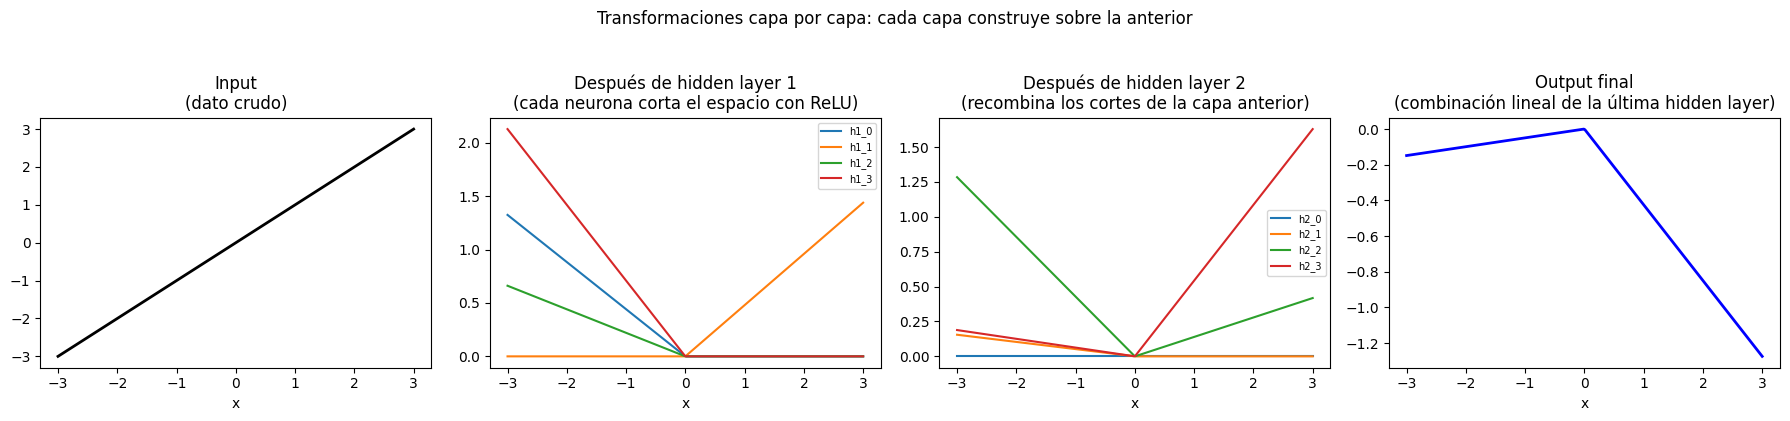

In [4]:
np.random.seed(15)
net = DeepNetwork([1, 4, 4, 1])

x_range = np.linspace(-3, 3, 300)
results = [net.forward(np.array([xi])) for xi in x_range]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Input
axes[0].plot(x_range, x_range, 'k-', lw=2)
axes[0].set_title('Input\n(dato crudo)')
axes[0].set_xlabel('x')

# After hidden layer 1
for j in range(4):
    axes[1].plot(x_range, [r[1][1][j] for r in results], label=f'h1_{j}')
axes[1].set_title('Después de hidden layer 1\n(cada neurona corta el espacio con ReLU)')
axes[1].legend(fontsize=7)
axes[1].set_xlabel('x')

# After hidden layer 2
for j in range(4):
    axes[2].plot(x_range, [r[1][2][j] for r in results], label=f'h2_{j}')
axes[2].set_title('Después de hidden layer 2\n(recombina los cortes de la capa anterior)')
axes[2].legend(fontsize=7)
axes[2].set_xlabel('x')

# Output
axes[3].plot(x_range, [r[0][0] for r in results], 'b-', lw=2)
axes[3].set_title('Output final\n(combinación lineal de la última hidden layer)')
axes[3].set_xlabel('x')

plt.suptitle('Transformaciones capa por capa: cada capa construye sobre la anterior', y=1.04)
plt.tight_layout()
plt.show()

Mirá lo que pasa:
1. **Layer 1**: cada neurona genera una función lineal cortada por ReLU. Son rectas que se ponen en 0 en algún punto.
2. **Layer 2**: cada neurona de la layer 2 toma como input las salidas de la layer 1 (que ya tienen cortes). Al aplicarle pesos + ReLU de nuevo, los cortes se **multiplican**. La layer 2 no ve el input original, ve el resultado transformado de la layer 1.
3. **Output**: combina todo linealmente. La función resultante tiene **más quiebres** que lo que podrías lograr con una sola capa del mismo tamaño.

---

<a id='comparacion'></a>
## 8. Comparación: shallow vs deep

Veamos la diferencia en práctica. Misma cantidad total de parámetros (aproximadamente), distinta distribución entre capas:

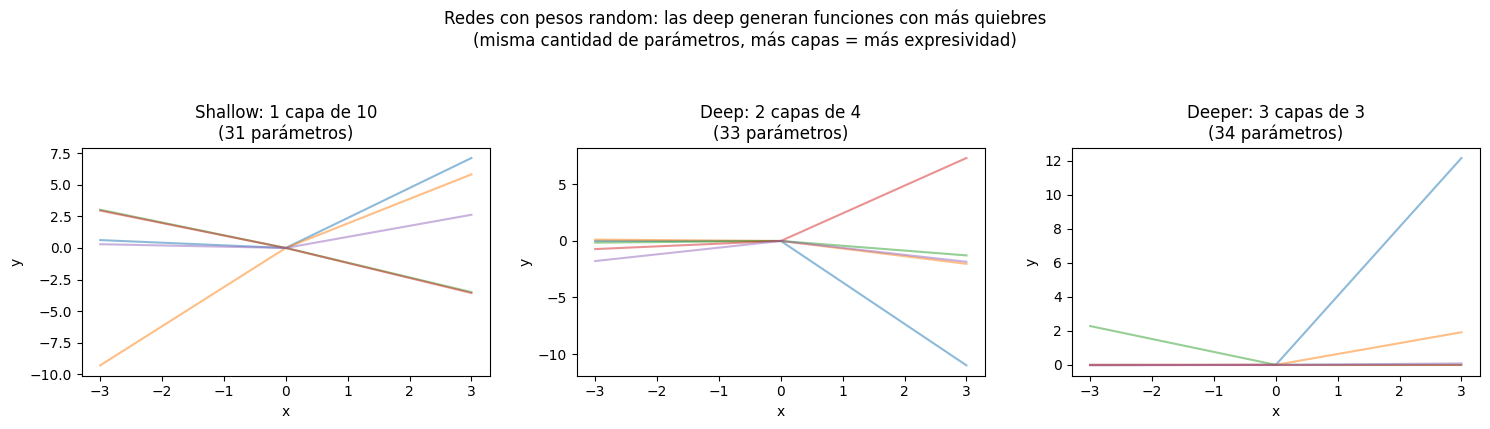

In [5]:
configs = [
    ([1, 10, 1], 'Shallow: 1 capa de 10'),
    ([1, 4, 4, 1], 'Deep: 2 capas de 4'),
    ([1, 3, 3, 3, 1], 'Deeper: 3 capas de 3'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_range = np.linspace(-3, 3, 300)

for ax, (sizes, label) in zip(axes, configs):
    net = DeepNetwork(sizes)
    n_params = net.count_params()
    
    # Plot 5 random initializations to see the variety of functions
    for seed in range(5):
        np.random.seed(seed)
        net = DeepNetwork(sizes)
        outputs = [net.forward(np.array([xi]))[0][0] for xi in x_range]
        ax.plot(x_range, outputs, alpha=0.5, lw=1.5)
    
    ax.set_title(f'{label}\n({n_params} parámetros)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.suptitle('Redes con pesos random: las deep generan funciones con más quiebres\n(misma cantidad de parámetros, más capas = más expresividad)', y=1.06)
plt.tight_layout()
plt.show()

Las redes más profundas tienden a generar funciones con **más quiebres y regiones** aun teniendo una cantidad similar de parámetros. Eso es lo que las hace más eficientes para representar funciones complejas.

### ¿Entonces siempre más capas es mejor?

No necesariamente. Redes muy profundas tienen problemas:
- **Vanishing/exploding gradients**: las señales de error se pierden o explotan al viajar por muchas capas
- **Más difíciles de entrenar**: necesitan técnicas especiales (que vamos a ver más adelante)

Pero con las técnicas correctas (buena inicialización, normalización, residual connections, etc.), las redes profundas funcionan increíblemente bien. Es por eso que se llama **deep** learning.

---

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **Deep network** | Múltiples hidden layers apiladas. Cada capa: transformación lineal + activación. |
| **Eficiencia** | Con los mismos parámetros, más capas = más regiones lineales = función más expresiva. |
| **Folding** | Cada capa "dobla" el espacio creado por la anterior, **multiplicando** las regiones (no sumando). |
| **Fully connected** | Cada neurona de una capa se conecta a todas las de la siguiente. También llamado "dense". |
| **Forward pass** | $\mathbf{h}_k = \text{ReLU}(\mathbf{W}_k \cdot \mathbf{h}_{k-1} + \mathbf{b}_k)$ para cada capa. |
| **Notación** | Matrices de pesos $\mathbf{W}$ y vectores de bias $\mathbf{b}$ por cada capa. |
| **Profundidad vs ancho** | Más profundidad (capas) es más eficiente que más ancho (neuronas por capa) para la misma cantidad de parámetros. |
| **Trade-off** | Redes muy profundas son más expresivas pero más difíciles de entrenar (problemas de gradientes). |

---

**Siguiente notebook →** [05 - Loss Functions](./05_loss_functions.ipynb): cómo construir funciones de pérdida con el framework probabilístico de Maximum Likelihood, en más detalle.